In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import gsw

In [2]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "stations/" + filename_lo
    filepath_ssc = "stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [14]:
print(data_lo[station]["salt"].attrs)

{'standard_name': 'sea_water_practical_salinity', 'long_name': 'salinity', 'time': 'ocean_time', 'cell_methods': 'ocean_time: mean', 'grid': 'grid', 'location': 'face', 'field': 'salinity', 'units': 'g kg-1'}


In [6]:
# read in observational data for each station
data_obs = pd.read_pickle("./combined_bottle_2014_cas7_t1_x11ab_ssc.pkl")
data_obs = data_obs["obs"]

# ensure datatime format 
data_obs["time"] = pd.to_datetime(data_obs["time"])


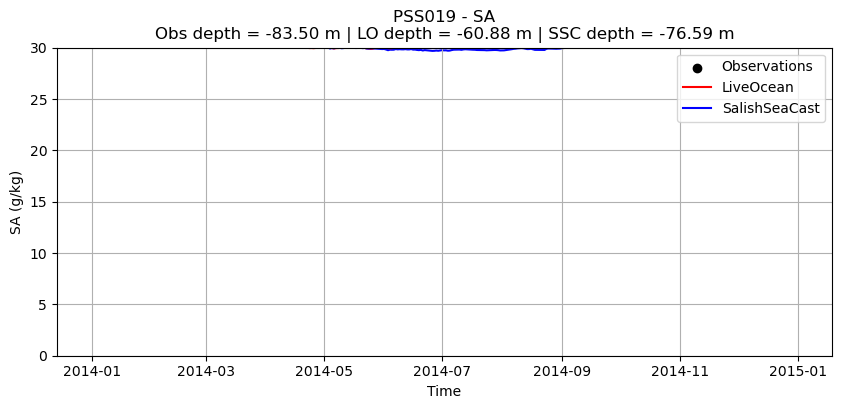

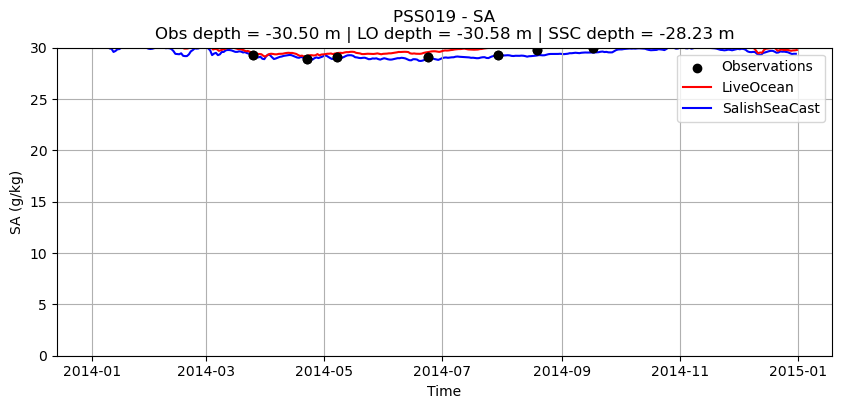

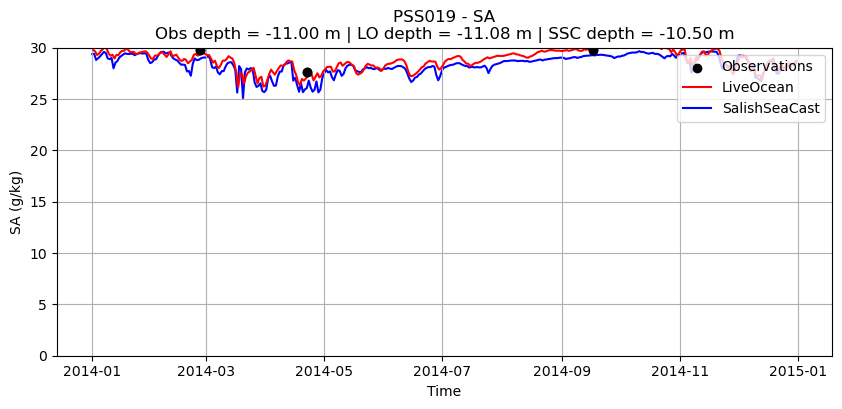

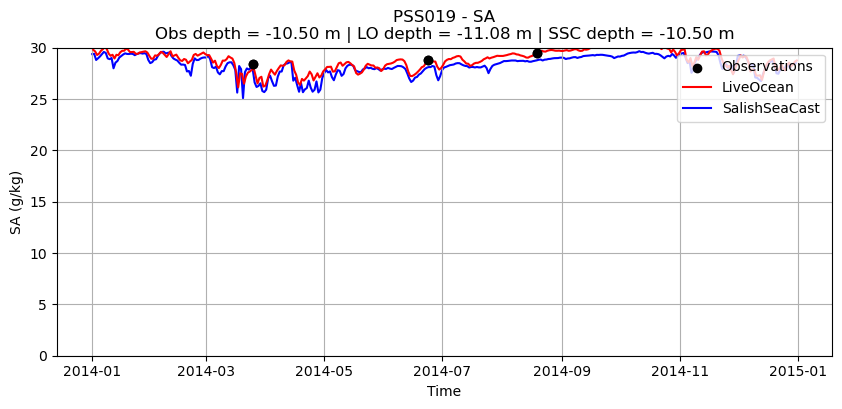

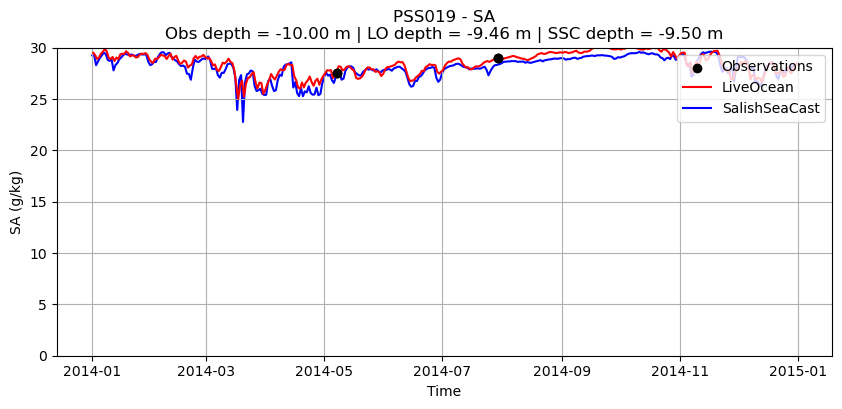

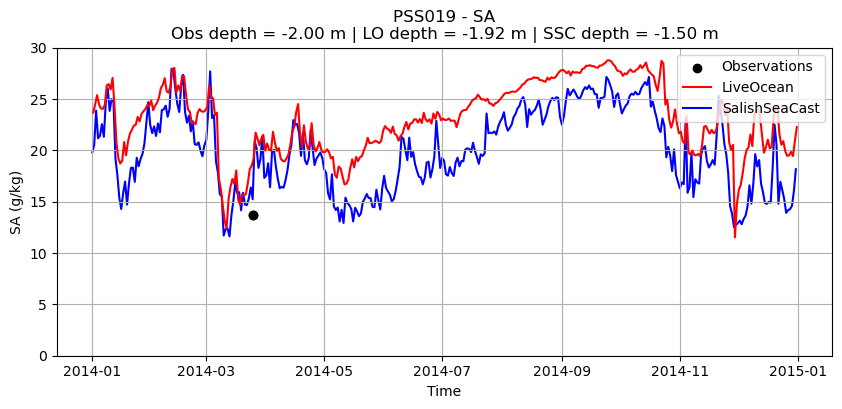

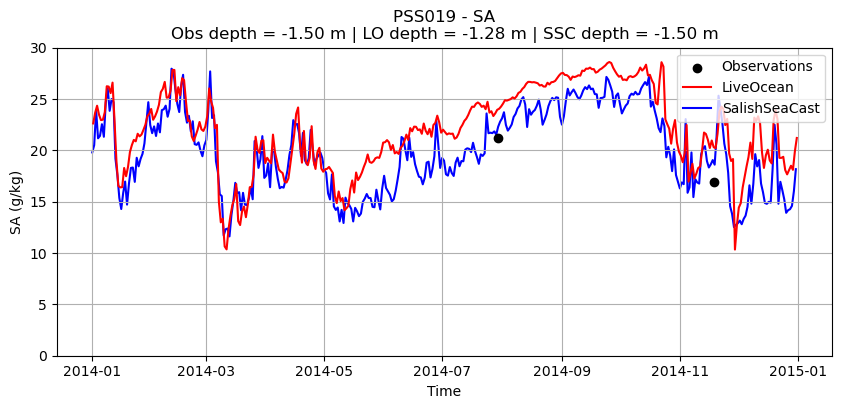

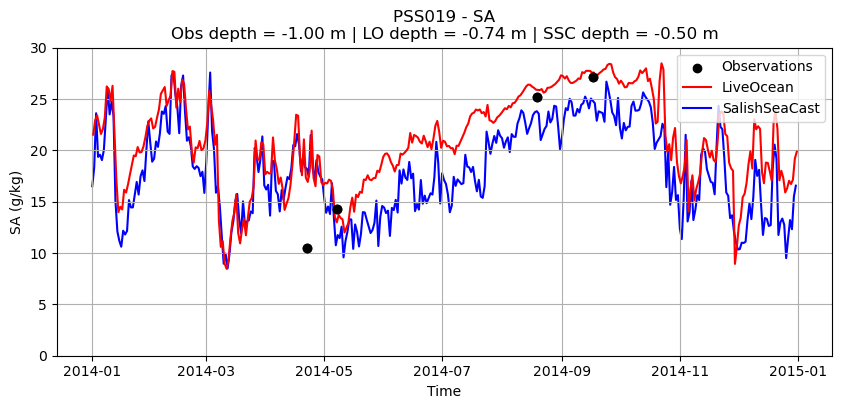

In [18]:
# station
station = "PSS019" # "GOR001" "CSE001" "HCB004" "HCB003" "CMB003" "SIN001" "EAP001" "ADM003" "PSS019" "SKG003" "SAR003"

# variable to plot
varname_ssc = "vosaline"
varname_lo = "salt"
varname_obs = "SA"

# select station data
ds_lo = data_lo[station]
ds_ssc = data_ssc[station]
ds_obs = data_obs[data_obs["name"] == station]

# unique observed depths
depths = np.sort(ds_obs["z"].dropna().unique())

for obs_depth in depths:
    # select observed data at this depth
    ds_obs_depth = ds_obs[ds_obs["z"] == obs_depth]

    # select model data at this depth
    ssc_depths = -ds_ssc["deptht"].values
    ssc_ind = np.abs(ssc_depths - obs_depth).argmin()
    ssc_model_depth = ssc_depths[ssc_ind]
    ds_ssc_depth = ds_ssc.isel(deptht=ssc_ind)
    
    # LO uses sigma coordinates, but depths stored in z_rho
    # LO depth selection
    lo_depths = ds_lo["z_rho"].mean(dim="ocean_time").values # z_rho is 2D array, so we take the mean over time to get a 1D array of depths
    lo_ind = np.argmin(np.abs(lo_depths - obs_depth))
    lo_model_depth = lo_depths[lo_ind]
    ds_lo_depth = ds_lo.isel(s_rho=lo_ind)

    # create figure
    plt.figure(figsize=(10, 4))

    # plot observed data
    plt.scatter(ds_obs_depth["time"], ds_obs_depth[varname_obs], color="black", label="Observations", zorder=3)

    # plot LO model data
    plt.plot(ds_lo_depth["ocean_time"], ds_lo_depth[varname_lo], color="red", label="LiveOcean", zorder=2)

    # plot SSC model data
    plt.plot(ds_ssc_depth["time_counter"], ds_ssc_depth[varname_ssc], color="blue", label="SalishSeaCast", zorder=1)

    plt.ylim(0, 30)  # set y-axis limits for better comparison
    
    plt.title(f"{station} - {varname_obs}\n"
              f"Obs depth = {obs_depth:.2f} m | " f"LO depth = {lo_model_depth:.2f} m | " f"SSC depth = {ssc_model_depth:.2f} m")
    
    # add labels and legend
    plt.xlabel("Time")
    plt.ylabel(varname_obs + " (g/kg)")
    plt.legend(loc="upper right")
    plt.grid()
    

    # show plot
    plt.show()